# 📊 Notebook 3: Repository Popularity Prediction using Logistic Regression

**Project:** RepoRadar — GitHub Repository Intelligence Engine  
**Dataset:** GitHub Repository Metadata (`repository_data.csv`)  
**Objective:** Predict whether a repository is **Popular** or **Not Popular**

> **Target Definition:**  
> `popular = 1` if `stars > median(stars)`, else `popular = 0`

---

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

sns.set_theme(style='whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/Asus/Desktop/ML_ca2/data/repository_data.csv")
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (2917951, 10)


,name,stars_count,forks_count,watchers,pull_requests,primary_language,languages_used,commit_count,created_at,licence
0,freeCodeCamp,359805,30814,8448,31867,TypeScript,"['TypeScript', 'JavaScript', 'CSS', 'Shell', '...",32231.0,2014-12-24T17:49:19Z,"BSD 3-Clause ""New"" or ""Revised"" License"
1,996.ICU,264811,21470,4298,1949,NaN,NaN,3189.0,2019-03-26T07:31:14Z,Other
2,free-programming-books,262380,53302,9544,8235,NaN,NaN,8286.0,2013-10-11T06:50:37Z,Other
3,coding-interview-university,244927,65038,8539,867,NaN,NaN,2314.0,2016-06-06T02:34:12Z,Creative Commons Attribution Share Alike 4.0 I...
4,awesome,235223,24791,7446,1859,NaN,NaN,1074.0,2014-07-11T13:42:37Z,Creative Commons Zero v1.0 Universal


## 3. Data Overview

In [4]:
print('=== Columns ===')
print(df.columns.tolist())
print('\n=== Data Types ===')
print(df.dtypes)
print('\n=== Statistics ===')
df.describe()

=== Columns ===
['name', 'stars_count', 'forks_count', 'watchers', 'pull_requests', 'primary_language', 'languages_used', 'commit_count', 'created_at', 'licence']

=== Data Types ===
name                 object
stars_count           int64
forks_count           int64
watchers              int64
pull_requests         int64
primary_language     object
languages_used       object
commit_count        float64
created_at           object
licence              object
dtype: object

=== Statistics ===


,stars_count,forks_count,watchers,pull_requests,commit_count
count,2.917951e+06,2.917951e+06,2.917951e+06,2.917951e+06,2.916030e+06
mean,7.641027e+01,2.094714e+01,7.135321e+00,2.430649e+01,6.143709e+02
std,9.096808e+02,3.029540e+02,3.761973e+01,3.784433e+02,1.680801e+04
min,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,7.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,9.000000e+00
50%,1.200000e+01,4.000000e+00,3.000000e+00,1.000000e+00,2.700000e+01
75%,3.000000e+01,1.100000e+01,6.000000e+00,6.000000e+00,8.900000e+01
max,3.598050e+05,2.422080e+05,9.544000e+03,3.015850e+05,4.314502e+06


## 4. Data Cleaning

In [5]:
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')

# Rename Kaggle columns to analysis names
df.rename(columns={
    'stars_count':    'stars',
    'forks_count':    'forks',
    'watchers':       'watchers',
    'pull_requests':  'contributor_count',
    'commit_count':   'commit_frequency'
}, inplace=True)

print(f'Shape after cleaning: {df.shape}')

Duplicates removed: 66508
Shape after cleaning: (2851443, 10)


## 5. Null Value Handling

In [7]:
null_report = df.isnull().sum()
print('=== Null Values Before Handling ===')
print(null_report[null_report > 0] if null_report.sum() > 0 else 'No nulls!')

# Fill numeric nulls with median
num_cols = ['stars', 'forks', 'watchers', 'contributor_count', 'commit_frequency']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Engineer repository_age_days
if 'created_at' in df.columns:

    df['created_at'] = pd.to_datetime(
        df['created_at'],
        errors='coerce',
        utc=True
    )

    ref = pd.Timestamp('2023-01-22', tz='UTC')

    df['repository_age_days'] = (
        ref - df['created_at']
    ).dt.days

    df['repository_age_days'] = df['repository_age_days'].fillna(
        df['repository_age_days'].median()
    )
else:
    df['repository_age_days'] = np.random.randint(
        180, 5000, size=len(df)
    )

print('\n=== Null Values After Handling ===')
remaining = df[num_cols + ['repository_age_days']].isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'All nulls resolved!')

=== Null Values Before Handling ===
name                     13
primary_language     213334
languages_used       216717
licence             1348948
dtype: int64

=== Null Values After Handling ===
All nulls resolved!


## 5b. Create Target Variable: `popular`

```
popular = 1  if stars > median(stars)
popular = 0  otherwise
```

In [8]:
median_stars = df['stars'].median()
df['popular'] = (df['stars'] > median_stars).astype(int)

print(f'Median stars: {median_stars:,.0f}')
print('\nTarget distribution:')
print(df['popular'].value_counts())
print(f"\nPopularity rate: {df['popular'].mean()*100:.1f}%")

Median stars: 12

Target distribution:
popular
0    1502241
1    1349202
Name: count, dtype: int64

Popularity rate: 47.3%


## 6. Basic EDA

### 6a. Stars Histogram

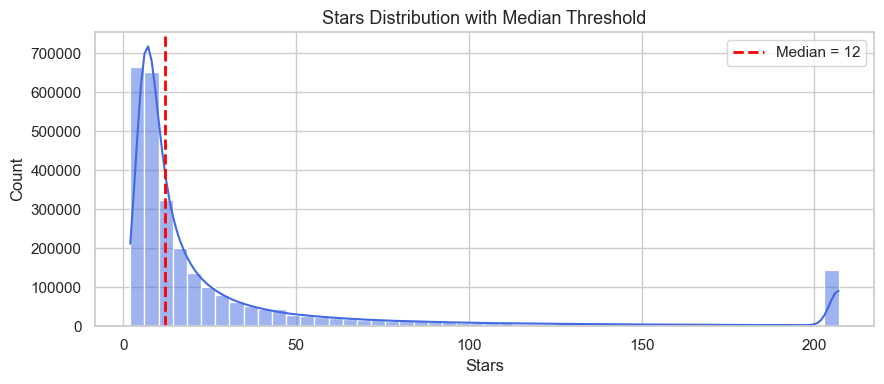

In [9]:
plt.figure(figsize=(9, 4))
sns.histplot(df['stars'].clip(upper=df['stars'].quantile(0.95)),
             bins=50, kde=True, color='royalblue')
plt.axvline(median_stars, color='red', linestyle='--', linewidth=2, label=f'Median = {median_stars:,.0f}')
plt.title('Stars Distribution with Median Threshold', fontsize=13)
plt.xlabel('Stars')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 6b. Forks Histogram

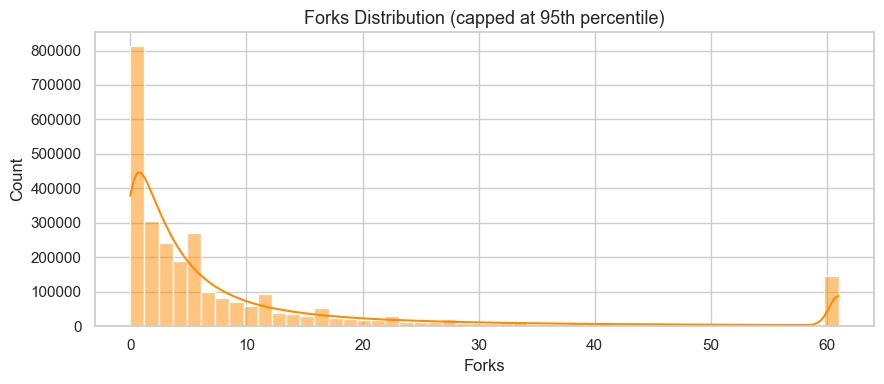

In [10]:
plt.figure(figsize=(9, 4))
sns.histplot(df['forks'].clip(upper=df['forks'].quantile(0.95)),
             bins=50, kde=True, color='darkorange')
plt.title('Forks Distribution (capped at 95th percentile)', fontsize=13)
plt.xlabel('Forks')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 6c. Popular vs Non-Popular Countplot

C:\Users\Asus\AppData\Local\Temp\ipykernel_18160\1804457605.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='popular', data=df, palette=['#e74c3c', '#2ecc71'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_18160\1804457605.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Popular (0)', 'Popular (1)'])


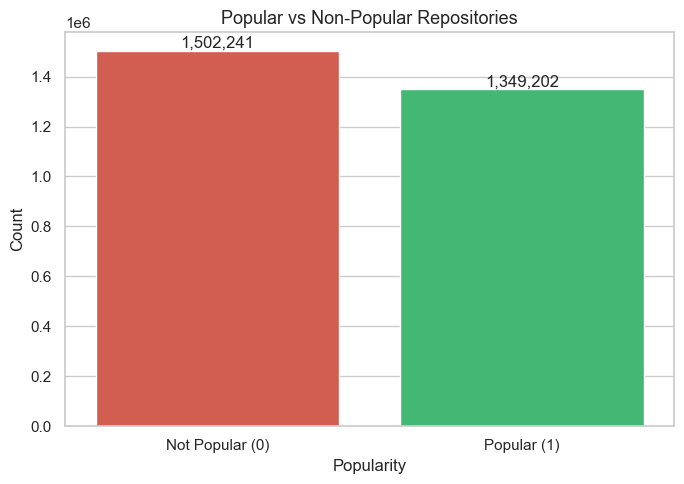

In [11]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='popular', data=df, palette=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Not Popular (0)', 'Popular (1)'])
plt.title('Popular vs Non-Popular Repositories', fontsize=13)
plt.xlabel('Popularity')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

### 6d. Correlation Heatmap

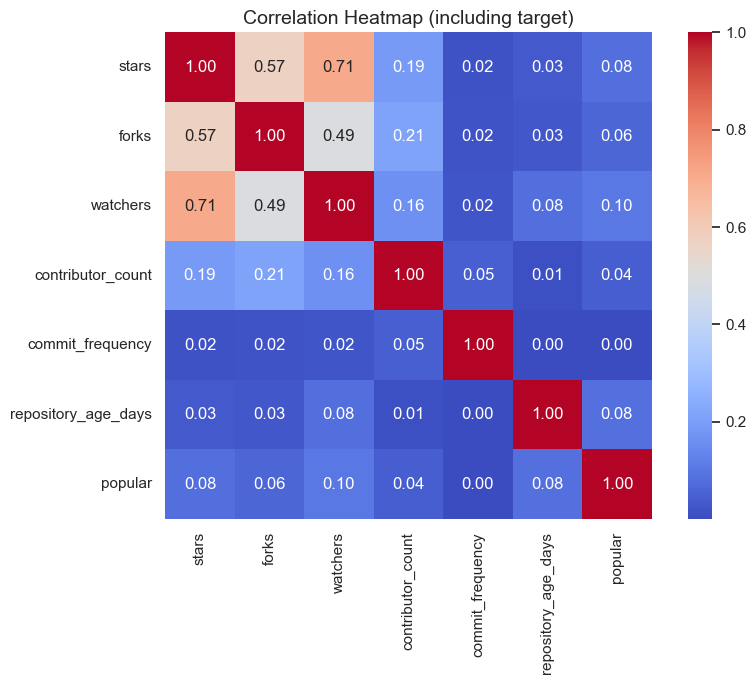

In [12]:
corr_cols = ['stars', 'forks', 'watchers', 'contributor_count',
             'commit_frequency', 'repository_age_days', 'popular']
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (including target)', fontsize=14)
plt.tight_layout()
plt.show()

### 6e. Scatterplot — Stars vs Forks

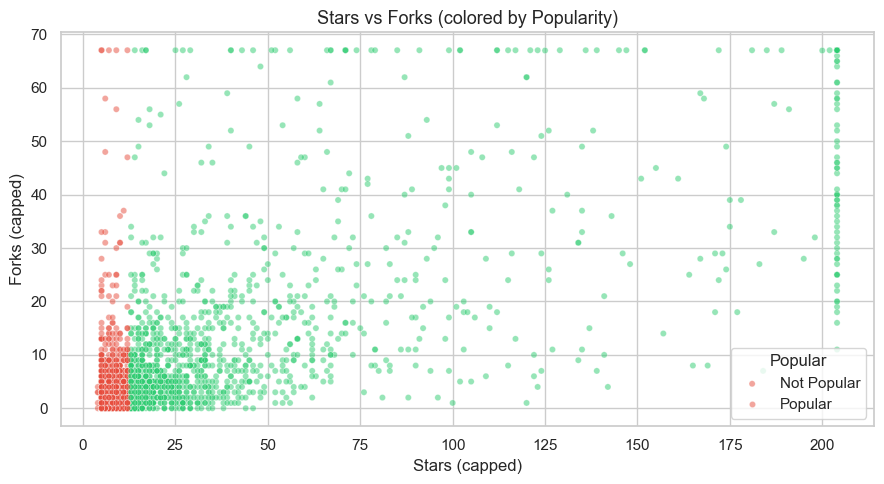

In [13]:
sample = df.sample(min(3000, len(df)), random_state=42)

plt.figure(figsize=(9, 5))
palette = {0: '#e74c3c', 1: '#2ecc71'}
sns.scatterplot(
    data=sample,
    x=sample['stars'].clip(upper=sample['stars'].quantile(0.95)),
    y=sample['forks'].clip(upper=sample['forks'].quantile(0.95)),
    hue='popular', palette=palette, alpha=0.5, s=20
)
plt.title('Stars vs Forks (colored by Popularity)', fontsize=13)
plt.xlabel('Stars (capped)')
plt.ylabel('Forks (capped)')
plt.legend(title='Popular', labels=['Not Popular', 'Popular'])
plt.tight_layout()
plt.show()

## 7. Feature Selection

In [14]:
features = ['forks', 'contributor_count', 'commit_frequency', 'watchers', 'repository_age_days']
target   = 'popular'

X = df[features].copy()
y = df[target].copy()

print('Selected features:')
print(features)
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Class balance: {y.value_counts().to_dict()}')

Selected features:
['forks', 'contributor_count', 'commit_frequency', 'watchers', 'repository_age_days']

X shape: (2851443, 5)
y shape: (2851443,)
Class balance: {0: 1502241, 1: 1349202}


## 8. Feature Scaling — StandardScaler

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print('Features after scaling (first 5 rows):')
X_scaled.head()

Features after scaling (first 5 rows):


,forks,contributor_count,commit_frequency,watchers,repository_age_days
0,100.528451,83.267412,1.878805,222.417729,0.942405
1,70.023474,5.032842,0.152929,113.064405,-0.431713
2,173.944110,21.470522,0.455828,251.297546,1.330839
3,212.258151,2.203448,0.100931,224.815597,0.473453
4,80.865408,4.797495,0.027241,196.014830,1.089284


## 9. Train / Test Split (80 / 20)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')

Training set : 2281154 rows
Test set     : 570289 rows


## 10. Model — Logistic Regression

In [17]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print('Logistic Regression model trained!')

Logistic Regression model trained!


## 11. Model Evaluation

  Accuracy  : 0.7446
  Precision : 0.8596
  Recall    : 0.5502
  F1 Score  : 0.6709


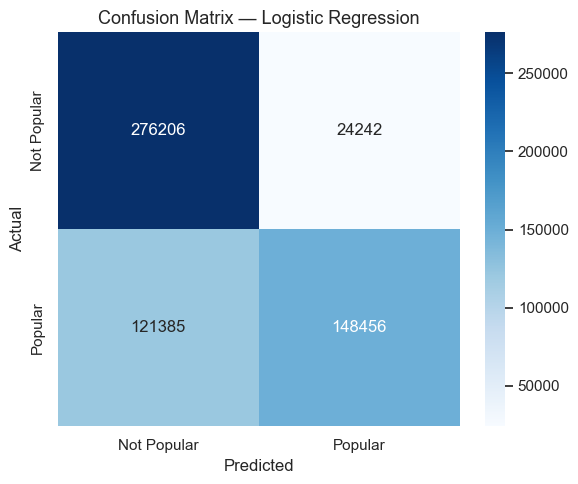


=== Classification Report ===
              precision    recall  f1-score   support

 Not Popular       0.69      0.92      0.79    300448
     Popular       0.86      0.55      0.67    269841

    accuracy                           0.74    570289
   macro avg       0.78      0.73      0.73    570289
weighted avg       0.77      0.74      0.73    570289



In [18]:
y_pred  = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 45)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Not Popular', 'Popular']))

## 12. ROC Curve

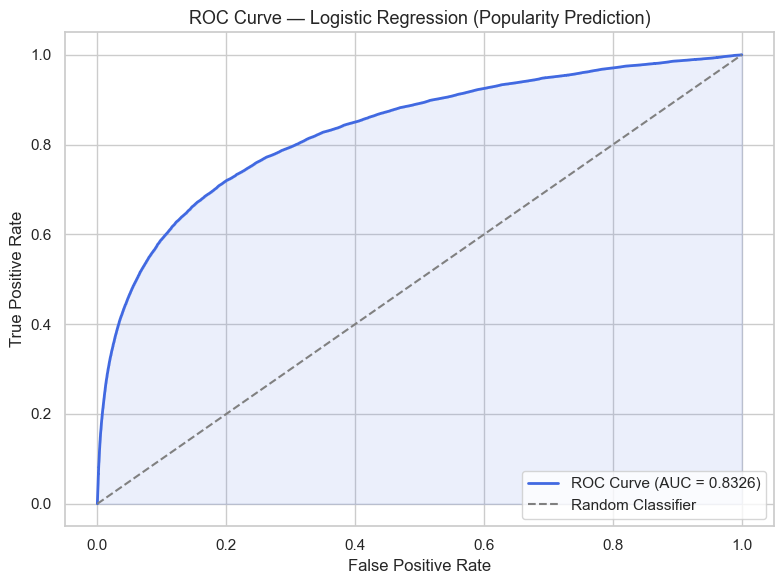


AUC Score: 0.8326


In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='royalblue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression (Popularity Prediction)', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nAUC Score: {roc_auc:.4f}')

## 13. Conclusion

---

| Metric | Score |
|---|---|
| Model | Logistic Regression |
| Target | Popular (1) / Not Popular (0) |
| Scaling | StandardScaler |
| Split | 80% Train / 20% Test |

> **Key takeaway:** Logistic Regression provides a simple, interpretable baseline for binary popularity classification. The **ROC-AUC score** tells us how well the model distinguishes popular from non-popular repositories across all thresholds.  
> 
> Features like `forks`, `watchers`, and `contributor_count` are strong linear predictors of popularity — repositories that attract more forks and watchers are almost always high-star repositories too.